# Clínica de Diagnóstico de Negocio — Grupo C, Caso B
## Predicción de ventas futuras (regresión)

**Propósito.** Estimar los ingresos mensuales de una sucursal un mes adelante para apoyar la planificación comercial. La variable objetivo es `ingresos_mensuales_UM`, continua y expresada en **unidades monetarias simuladas (UM)**; no representa facturación real ni una moneda verificada. La pregunta de negocio es: *con la información disponible al cierre del mes anterior y con escenarios comerciales planificados, ¿qué ingresos cabe esperar el mes siguiente?*

**Alcance del ejercicio.** El archivo de clientes originalmente suministrado no era una serie de ventas mensuales. Su mediana agregada de gasto (396, periodo desconocido) quedó documentada como referencia de escala; el notebook no requiere ese archivo para ejecutarse. El **único CSV operativo del Caso B** es `Sales Prediction.csv`, con datos simulados. El resultado no debe usarse para aprobar presupuestos o tomar decisiones económicas reales. La jurisdicción de referencia para la discusión de privacidad es **El Salvador**.

## 1. Descripción del problema de negocio y criterio de éxito

- **Decisión apoyada:** asignación tentativa de presupuesto de marketing y planificación de capacidad por sucursal. Un error alto puede ocasionar inventario/capacidad insuficiente o gasto innecesario.
- **Unidad de análisis:** sucursal-mes, no cliente. Se simulan 15 sucursales × 24 meses (360 filas), de enero de 2024 a diciembre de 2025.
- **Tipo de tarea:** regresión supervisada, porque los ingresos son continuos. La predicción es **a un mes** y exige conocer los ingresos del mes anterior; no equivale a un pronóstico de varios meses sin actualizar datos.
- **Criterio técnico:** comparar MAE, RMSE y R² en meses futuros separados temporalmente. Se prioriza RMSE de validación por el costo de errores grandes, sin ocultar MAE ni la escala de ingresos.
- **Criterio de adopción:** se requiere además superar al pronóstico ingenuo del último mes, validar con ingresos reales de la organización, documentar el costo del error y monitorear la deriva. Ninguna métrica sobre datos simulados demuestra utilidad operacional.

## 2. Mapa de selección de algoritmos

| Decisión | Justificación |
|---|---|
| Variable objetivo | `ingresos_mensuales_UM` es continua → regresión, no clasificación. |
| Contexto | 360 filas; interpretabilidad y pronóstico a un mes; variables previstas o disponibles al inicio del mes. |
| Regresión Ridge | Modelo lineal regularizado, estable e interpretable a nivel de dirección general; limita coeficientes grandes. Puede fallar ante relaciones no lineales y shocks. |
| Random Forest Regressor | Captura interacciones/no linealidad sin especificarlas. Menos transparente y puede extrapolar mal a meses o niveles de ingresos fuera del entrenamiento. |
| Modelo ingenuo | Usar los ingresos del mes anterior; referencia mínima de valor práctico. |
| Selección | Menor RMSE de validación; si Ridge queda a ≤5 % del mejor, se prefiere por interpretabilidad. El test futuro se consulta **después** de elegir. |

No se usan `ID`, `Income`, edad, educación, estado civil, fecha de alta ni `Response`: son datos individuales o no guardan la semántica temporal requerida. Tampoco se usa el ingreso del mes actual como predictor.

## 3. Simulación y exploración de datos
### Auditoría del origen y construcción del dataset

La auditoría previa encontró 2,240 clientes y 29 columnas en el archivo originalmente suministrado, que estaba **separado por tabulaciones** pese a su extensión `.csv`. Registraba atributos y gastos acumulados por cliente (`Mnt*`) y fecha de alta (`Dt_Customer`). Esta fecha **no es una fecha de venta** y no permite reconstruir ingresos mensuales. Tampoco había presupuesto histórico de marketing, precios, competencia o contexto macroeconómico. `Income` era ingreso del cliente, **no ingreso de la empresa**. Por ello, no se reetiquetó ninguna columna como venta mensual.

En la auditoría previa se registró una mediana agregada de gasto de **396**, pero el archivo original ya no se adjunta y ese cálculo **no puede reproducirse con esta entrega**. Aquí 396 se usa solo como parámetro ilustrativo de escala, no como venta ni facturación observada. El periodo de esos gastos es desconocido. Las fechas, sucursales, predictores y objetivo del único CSV del Caso B son simulados y están rotulados como tales. No se exportan identificadores ni atributos demográficos individuales.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
ROOT = Path.cwd()
DERIVED = ROOT / "Sales Prediction.csv"
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Único CSV operativo del Caso B: {DERIVED.name}")

Único CSV operativo del Caso B: Sales Prediction.csv


In [2]:
anchor = 396.0  # mediana agregada verificada en la auditoría del archivo original
print("Origen auditado: 2,240 clientes × 29 columnas; 24 ingresos personales faltantes.")
print("Las fechas de alta iban de 2012-07-30 a 2014-06-29; no eran fechas de venta.")
print(f"Ancla de gasto acumulado: {anchor:,.2f} (periodo desconocido).")
print("No se requieren ni se usan registros individuales para ejecutar el Caso B.")

Origen auditado: 2,240 clientes × 29 columnas; 24 ingresos personales faltantes.
Las fechas de alta iban de 2012-07-30 a 2014-06-29; no eran fechas de venta.
Ancla de gasto acumulado: 396.00 (periodo desconocido).
No se requieren ni se usan registros individuales para ejecutar el Caso B.


In [3]:
# Todas las observaciones de la tabla siguiente son sintéticas. El ancla solo
# calibra una magnitud hipotética: 100 clientes-equivalentes por sucursal-mes.
rng = np.random.default_rng(SEED)
months = pd.date_range("2024-01-01", periods=24, freq="MS")
stores = [f"S{i:02d}" for i in range(1, 16)]
store_scale = dict(zip(stores, rng.uniform(0.75, 1.35, len(stores))))
previous = {store: anchor * 100 * store_scale[store] for store in stores}
rows = []

for t, month in enumerate(months):
    angle = 2 * np.pi * (month.month - 1) / 12
    for store in stores:
        scale = store_scale[store]
        marketing = max(500, 1800 + 500 * scale + 15 * t + 350 * np.sin(angle)
                        + rng.normal(0, 220))
        price = 100 + 0.10 * t + rng.normal(0, 1.8)
        competition = 100 + 0.04 * t + rng.normal(0, 3.0)
        macro = 100 + 0.20 * t + rng.normal(0, 1.0)
        lag_1 = previous[store]
        expected = (
            anchor * 100 * scale * (1 + 0.007 * t)
            + 2.8 * marketing
            + 280 * (price - 100)
            - 230 * (competition - 100)
            + 150 * (macro - 100)
            + 3500 * np.sin(angle) + 1000 * np.cos(angle)
        )
        shock = rng.choice([-15000, 15000]) if rng.random() < 0.02 else 0
        revenue = max(1000, 0.33 * lag_1 + 0.67 * expected
                      + rng.normal(0, 2500) + shock)
        rows.append({
            "mes": month.strftime("%Y-%m-%d"),
            "sucursal_sintetica": store,
            "indice_mes": t,
            "escala_sucursal_simulada": scale,
            "presupuesto_marketing_plan_UM": marketing,
            "indice_precio_plan": price,
            "indice_competencia_escenario": competition,
            "indice_macro_escenario": macro,
            "estacionalidad_seno": np.sin(angle),
            "estacionalidad_coseno": np.cos(angle),
            "ingresos_mes_anterior_UM": lag_1,
            "ingresos_mensuales_UM": revenue,
            "origen": "simulado; ancla agregada de gasto historico sin periodo conocido",
        })
        previous[store] = revenue

sales = pd.DataFrame(rows).sort_values(["mes", "sucursal_sintetica"]).reset_index(drop=True)
assert len(sales) >= 200 and len(sales) == 15 * 24
assert not sales.isna().any().any()
assert (sales["ingresos_mensuales_UM"] > 0).all()
sales.to_csv(DERIVED, index=False, encoding="utf-8", float_format="%.4f")
sales = pd.read_csv(DERIVED, encoding="utf-8")
assert len(sales) == 360 and sales["mes"].nunique() == 24
assert sales["origen"].str.startswith("simulado").all()
print(f"Dataset adaptado: {sales.shape[0]} sucursal-meses; {sales['sucursal_sintetica'].nunique()} sucursales; {sales['mes'].nunique()} meses")
print(f"Archivo único creado y leído para el análisis: {DERIVED.name}")
print("TODOS los ingresos mensuales y predictores de este archivo son simulados.")
display(sales.head())

Dataset adaptado: 360 sucursal-meses; 15 sucursales; 24 meses
Archivo único creado y leído para el análisis: Sales Prediction.csv
TODOS los ingresos mensuales y predictores de este archivo son simulados.


,mes,sucursal_sintetica,indice_mes,escala_sucursal_simulada,presupuesto_marketing_plan_UM,indice_precio_plan,indice_competencia_escenario,indice_macro_escenario,estacionalidad_seno,estacionalidad_coseno,ingresos_mes_anterior_UM,ingresos_mensuales_UM,origen
0,2024-01-01,S01,0,1.2144,2218.1425,100.6638,97.1234,100.8785,0.0,1.0,48089.1957,53114.3705,simulado; ancla agregada de gasto historico si...
1,2024-01-01,S02,0,1.0133,2156.8590,102.2006,99.5364,99.5717,0.0,1.0,40127.7517,46616.0120,simulado; ancla agregada de gasto historico si...
2,2024-01-01,S03,0,1.2652,2512.9771,100.7429,101.2925,102.1416,0.0,1.0,50100.2866,54359.4633,simulado; ancla agregada de gasto historico si...
3,2024-01-01,S04,0,1.1684,2205.1804,101.1088,103.3869,99.8861,0.0,1.0,46269.4644,48689.8081,simulado; ancla agregada de gasto historico si...
4,2024-01-01,S05,0,0.8065,2346.3836,101.3379,101.6295,99.3345,0.0,1.0,31937.6538,37234.1821,simulado; ancla agregada de gasto historico si...


### Exploración de datos (EDA)

La EDA verifica tamaño, faltantes, distribución, valores extremos y patrones estacionales de la **simulación**. Las asociaciones observadas no prueban causalidad: marketing, precios, competencia y macroeconomía fueron generados mediante supuestos. Cualquier choque extremo se mantiene inicialmente para evaluar sensibilidad; su eliminación posterior se hará solo en el conjunto de entrenamiento.

Faltantes por columna:


,mes,sucursal_sintetica,indice_mes,escala_sucursal_simulada,presupuesto_marketing_plan_UM,indice_precio_plan,indice_competencia_escenario,indice_macro_escenario,estacionalidad_seno,estacionalidad_coseno,ingresos_mes_anterior_UM,ingresos_mensuales_UM,origen
nulos,0,0,0,0,0,0,0,0,0,0,0,0,0


Resumen de ingresos mensuales simulados:


,count,mean,std,min,25%,50%,75%,max
ingresos_mensuales_UM,360.0,55080.06,8534.1,34633.97,48785.06,56014.18,61493.4,75107.77


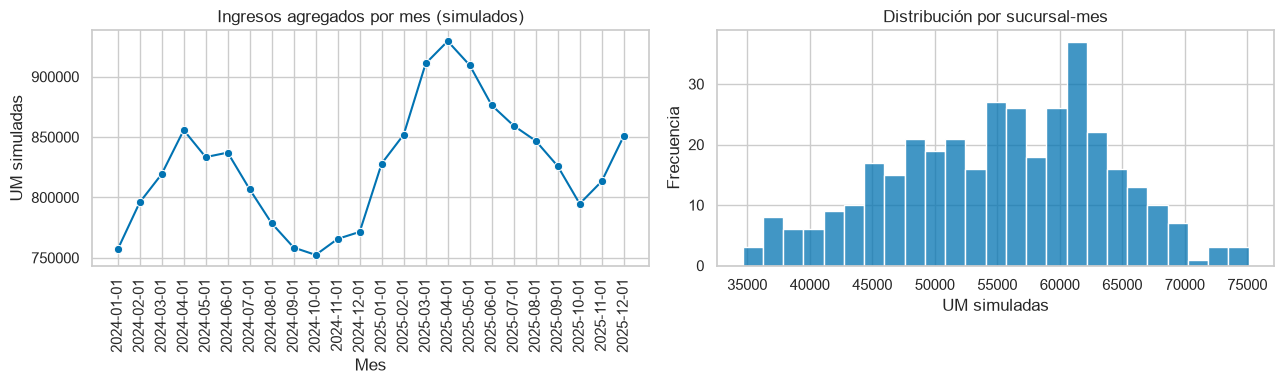

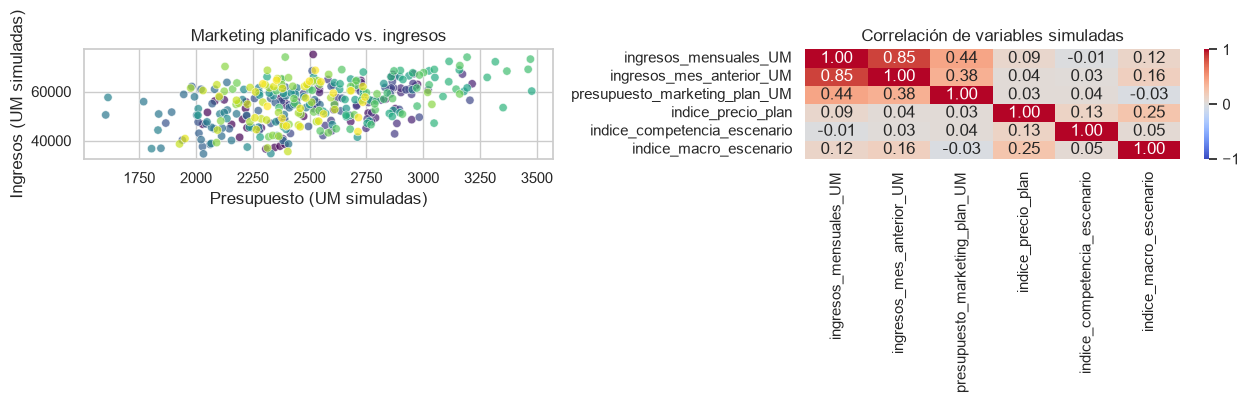

In [4]:
print("Faltantes por columna:")
display(sales.isna().sum().to_frame("nulos").T)
print("Resumen de ingresos mensuales simulados:")
display(sales["ingresos_mensuales_UM"].describe().round(2).to_frame().T)

monthly = sales.groupby("mes", as_index=False)["ingresos_mensuales_UM"].sum()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=monthly, x="mes", y="ingresos_mensuales_UM", marker="o", ax=ax[0])
ax[0].tick_params(axis="x", rotation=90)
ax[0].set(title="Ingresos agregados por mes (simulados)", xlabel="Mes", ylabel="UM simuladas")
sns.histplot(data=sales, x="ingresos_mensuales_UM", bins=25, ax=ax[1])
ax[1].set(title="Distribución por sucursal-mes", xlabel="UM simuladas", ylabel="Frecuencia")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=sales, x="presupuesto_marketing_plan_UM", y="ingresos_mensuales_UM",
                hue="indice_mes", palette="viridis", legend=False, alpha=.7, ax=ax[0])
ax[0].set(title="Marketing planificado vs. ingresos", xlabel="Presupuesto (UM simuladas)", ylabel="Ingresos (UM simuladas)")
heat_cols = ["ingresos_mensuales_UM", "ingresos_mes_anterior_UM",
             "presupuesto_marketing_plan_UM", "indice_precio_plan",
             "indice_competencia_escenario", "indice_macro_escenario"]
sns.heatmap(sales[heat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax[1])
ax[1].set(title="Correlación de variables simuladas")
plt.tight_layout()
plt.show()

**Interpretación de la EDA.** El CSV generado contiene 360 observaciones completas y ningún par sucursal-mes duplicado. El ingreso simulado medio es 55,080.06 UM, con un rango de 34,633.97 a 75,107.77 UM. La media por sucursal-mes aumenta de 52,953.02 UM en 2024 a 57,207.10 UM en 2025; este crecimiento fue introducido por la regla de simulación y no demuestra una tendencia comercial real. La dispersión entre sucursales y los choques extremos justifican revisar errores y atípicos por separado más adelante. Las correlaciones del mapa de calor son descriptivas y no estiman efectos causales.

## 4. Implementación y comparación de modelos

Se separan **meses completos** de forma cronológica usando `train_test_split(shuffle=False)`: 14 meses para ajuste inicial, 4 para validación/selección y 6 meses futuros para prueba final. Esta partición evita mezclar sucursales de un mismo mes entre conjuntos. El escalado de Ridge se ajusta dentro de `Pipeline`, exclusivamente sobre los datos de entrenamiento de cada etapa. Los escenarios de marketing, precio, competencia y macro deben estar disponibles **antes** del mes pronosticado; de otro modo hay fuga de información. El primer `lag_1` es un valor inicial simulado.

In [5]:
feature_cols = [
    "indice_mes", "escala_sucursal_simulada", "presupuesto_marketing_plan_UM",
    "indice_precio_plan", "indice_competencia_escenario",
    "indice_macro_escenario", "estacionalidad_seno", "estacionalidad_coseno",
    "ingresos_mes_anterior_UM",
]
target = "ingresos_mensuales_UM"
all_months = np.array(sorted(sales["mes"].unique()))
months_dev, months_test = train_test_split(all_months, test_size=6, shuffle=False)
months_fit, months_val = train_test_split(months_dev, test_size=4, shuffle=False)

fit = sales[sales["mes"].isin(months_fit)].copy()
val = sales[sales["mes"].isin(months_val)].copy()
dev = sales[sales["mes"].isin(months_dev)].copy()
test = sales[sales["mes"].isin(months_test)].copy()
assert max(months_fit) < min(months_val) < min(months_test)
print(f"Ajuste: {len(months_fit)} meses / {len(fit)} filas ({months_fit[0]} a {months_fit[-1]})")
print(f"Validación: {len(months_val)} meses / {len(val)} filas ({months_val[0]} a {months_val[-1]})")
print(f"Prueba futura: {len(months_test)} meses / {len(test)} filas ({months_test[0]} a {months_test[-1]})")

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

candidates = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, max_features=0.8,
        random_state=SEED, n_jobs=-1,
    ),
}
val_rows = []
for name, model in candidates.items():
    fitted = clone(model).fit(fit[feature_cols], fit[target])
    val_rows.append({"modelo": name, **metrics(val[target], fitted.predict(val[feature_cols]))})
val_results = pd.DataFrame(val_rows).sort_values("RMSE").reset_index(drop=True)
display(val_results.round(3))

best_rmse = val_results["RMSE"].min()
ridge_rmse = val_results.set_index("modelo").loc["Ridge", "RMSE"]
selected = "Ridge" if ridge_rmse <= best_rmse * 1.05 else val_results.iloc[0]["modelo"]
print(f"Modelo seleccionado antes de ver el test: {selected}")

Ajuste: 14 meses / 210 filas (2024-01-01 a 2025-02-01)
Validación: 4 meses / 60 filas (2025-03-01 a 2025-06-01)
Prueba futura: 6 meses / 90 filas (2025-07-01 a 2025-12-01)


,modelo,MAE,RMSE,R2
0,Ridge,2464.251,3072.531,0.848
1,Random Forest,4028.444,4808.799,0.627


Modelo seleccionado antes de ver el test: Ridge


,modelo,conjunto,MAE,RMSE,R2
0,Ridge,desarrollo,2212.074,3212.186,0.859
1,Ridge,prueba futura,2321.696,3330.421,0.844
2,Random Forest,desarrollo,1562.149,2225.664,0.932
3,Random Forest,prueba futura,2831.734,3883.634,0.787
4,Último mes,prueba futura,3403.551,4397.413,0.727


RMSE frente al último mes: +24.3% de mejora simulada
RMSE / ingreso medio del test: 6.0%


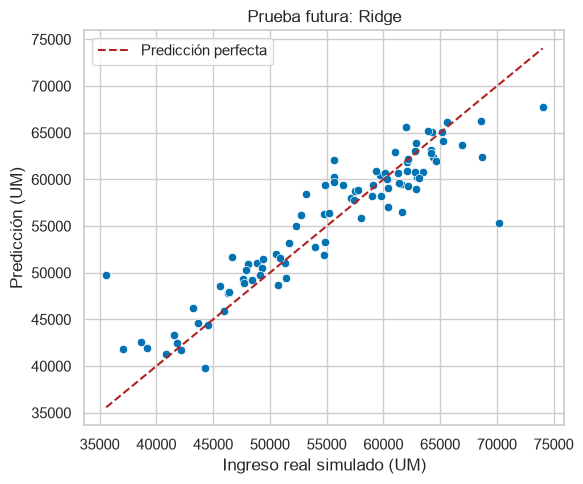

In [6]:
results = []
trained = {}
for name, model in candidates.items():
    fitted = clone(model).fit(dev[feature_cols], dev[target])
    trained[name] = fitted
    results.append({"modelo": name, "conjunto": "desarrollo", **metrics(dev[target], fitted.predict(dev[feature_cols]))})
    results.append({"modelo": name, "conjunto": "prueba futura", **metrics(test[target], fitted.predict(test[feature_cols]))})

results.append({"modelo": "Último mes", "conjunto": "prueba futura",
                **metrics(test[target], test["ingresos_mes_anterior_UM"])})
comparison = pd.DataFrame(results)
display(comparison.round(3))

chosen = trained[selected]
pred_test = chosen.predict(test[feature_cols])
chosen_test = metrics(test[target], pred_test)
baseline_test = metrics(test[target], test["ingresos_mes_anterior_UM"])
improvement = 100 * (baseline_test["RMSE"] - chosen_test["RMSE"]) / baseline_test["RMSE"]
print(f"RMSE frente al último mes: {improvement:+.1f}% de mejora simulada")
print(f"RMSE / ingreso medio del test: {chosen_test['RMSE'] / test[target].mean():.1%}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=test[target], y=pred_test, ax=ax)
limits = [min(test[target].min(), pred_test.min()), max(test[target].max(), pred_test.max())]
ax.plot(limits, limits, "--", color="firebrick", label="Predicción perfecta")
ax.set(xlabel="Ingreso real simulado (UM)", ylabel="Predicción (UM)",
       title=f"Prueba futura: {selected}")
ax.legend()
plt.tight_layout()
plt.show()

### Verificación de supuesto y diagnóstico

Para Ridge se inspecciona la **linealidad aproximada**: los residuos de validación deberían oscilar alrededor de cero sin curvatura marcada al graficarlos contra los valores predichos. También se calcula la correlación de residuos consecutivos por sucursal para alertar sobre dependencia temporal. Estas comprobaciones son diagnósticos, **no pruebas definitivas**. Si se selecciona Random Forest, se examina su sensibilidad a extrapolación comparando error en meses futuros y en desarrollo; el bosque no exige linealidad, pero sí representatividad de rangos y patrones.

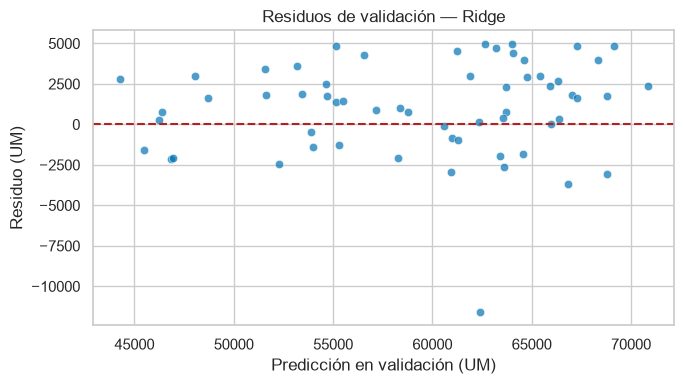

Mediana de correlación temporal lag-1 de residuos por sucursal: -0.063
Interpretación: buscar patrón/curvatura en el gráfico; 4 meses de validación limitan esta prueba.


In [7]:
diagnostic_model = clone(candidates[selected]).fit(fit[feature_cols], fit[target])
val_pred = diagnostic_model.predict(val[feature_cols])
residuals = val[target].to_numpy() - val_pred
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=val_pred, y=residuals, ax=ax, alpha=.7)
ax.axhline(0, color="firebrick", linestyle="--")
ax.set(xlabel="Predicción en validación (UM)", ylabel="Residuo (UM)",
       title=f"Residuos de validación — {selected}")
plt.tight_layout()
plt.show()

val_diag = val[["mes", "sucursal_sintetica"]].copy()
val_diag["residuo"] = residuals
lag_corrs = []
for _, group in val_diag.groupby("sucursal_sintetica"):
    r = group.sort_values("mes")["residuo"].to_numpy()
    if np.std(r[:-1]) > 0 and np.std(r[1:]) > 0:
        lag_corrs.append(np.corrcoef(r[:-1], r[1:])[0, 1])
print(f"Mediana de correlación temporal lag-1 de residuos por sucursal: {np.median(lag_corrs):+.3f}")
print("Interpretación: buscar patrón/curvatura en el gráfico; 4 meses de validación limitan esta prueba.")

**Resultado de la verificación para Ridge.** En el gráfico de validación no aparece una curvatura en U clara, pero los residuos son predominantemente positivos; al agrupar las 60 predicciones en cuatro rangos iguales, los residuos medios son aproximadamente +606, +1,083, +710 y +1,730 UM. Esto señala subpredicción, especialmente en el rango alto, por lo que **no se puede afirmar que el supuesto de relación lineal y calibración se cumpla plenamente**. La mediana de correlación temporal de residuos es −0.063, pero cada sucursal aporta solo cuatro meses de validación. La prueba es exploratoria y debe repetirse con datos reales y más periodos.

## 5. Análisis de límites y riesgos

1. **Representatividad y sesgo de diseño:** las ventas, campañas, precios, competencia, macroeconomía y sucursales son simuladas; el archivo de clientes no valida ninguno de esos procesos. La regla generadora es principalmente lineal, por lo que esta comparación puede favorecer a Ridge por construcción. El buen desempeño mide la capacidad de recuperar esa regla sintética, no ventas reales.
2. **Sobreajuste y deriva:** la brecha RMSE entre desarrollo y prueba futura es +74.5 % para Random Forest y +3.7 % para Ridge en esta ejecución. Una brecha grande sugiere posible sobreajuste o cambio temporal, pero no distingue por sí sola la causa. Random Forest puede extrapolar mal fuera del rango de entrenamiento.
3. **Sesgo y variables omitidas:** no se incluyen cierres, promociones no planificadas, clima, ruptura de inventario, feriados reales ni cambios económicos observados. Los efectos de marketing/precio en la simulación son supuestos, no inferencia causal.
4. **Atípicos:** los shocks sintéticos pueden representar eventos excepcionales legítimos. Se detectaron 3 entre 270 filas de desarrollo; retirarlos solo del entrenamiento empeoró ligeramente el RMSE futuro de Ridge (3,330.42 a 3,333.16 UM). No se borran del test ni se recomienda eliminarlos automáticamente en producción.
5. **Disponibilidad e interpretabilidad:** el pronóstico requiere ingreso previo verificado y escenarios disponibles ex ante. Ridge es más fácil de explicar por contribuciones aproximadas, pero correlación y multicolinealidad impiden leer coeficientes como efectos causales.

In [8]:
# Umbrales por sucursal: un IQR global ocultaría shocks de una sucursal
# pequeña bajo la variación estructural entre sucursales.
quartiles = dev.groupby("sucursal_sintetica")[target].quantile([.25, .75]).unstack()
limits = dev[["sucursal_sintetica", target]].join(quartiles, on="sucursal_sintetica")
spread = limits[0.75] - limits[0.25]
is_outlier = (limits[target] < limits[0.25] - 1.5 * spread) | (
    limits[target] > limits[0.75] + 1.5 * spread
)
dev_trim = dev.loc[~is_outlier]
trim_model = clone(candidates[selected]).fit(dev_trim[feature_cols], dev_trim[target])
trim_test = metrics(test[target], trim_model.predict(test[feature_cols]))
print(f"Atípicos detectados en desarrollo con IQR por sucursal: {is_outlier.sum()} / {len(dev)}")
print(f"RMSE test con todos: {chosen_test['RMSE']:,.2f} UM; sin atípicos de entrenamiento: {trim_test['RMSE']:,.2f} UM")
print("La dirección del cambio es descriptiva; no justifica borrar eventos reales automáticamente.")

gap = comparison.pivot(index="modelo", columns="conjunto", values="RMSE")
gap = gap.dropna(subset=["desarrollo", "prueba futura"])
gap["brecha_relativa"] = gap["prueba futura"] / gap["desarrollo"] - 1
display(gap.round(3))
for model_name, row in gap.iterrows():
    print(f"{model_name}: brecha RMSE prueba/desarrollo {row['brecha_relativa']:+.1%}; "
          "indicio de posible sobreajuste o cambio temporal, no diagnóstico causal.")

Atípicos detectados en desarrollo con IQR por sucursal: 3 / 270
RMSE test con todos: 3,330.42 UM; sin atípicos de entrenamiento: 3,333.16 UM
La dirección del cambio es descriptiva; no justifica borrar eventos reales automáticamente.


conjunto,desarrollo,prueba futura,brecha_relativa
modelo,,,
Random Forest,2225.664,3883.634,0.745
Ridge,3212.186,3330.421,0.037


Random Forest: brecha RMSE prueba/desarrollo +74.5%; indicio de posible sobreajuste o cambio temporal, no diagnóstico causal.
Ridge: brecha RMSE prueba/desarrollo +3.7%; indicio de posible sobreajuste o cambio temporal, no diagnóstico causal.


## 6. Consideraciones éticas, privacidad y transparencia

- **Privacidad (El Salvador):** según la auditoría previa, el archivo de origen contenía identificador y atributos de personas (`ID`, año de nacimiento, educación, estado civil e ingreso personal); ese archivo no se adjunta y la auditoría no puede repetirse con esta entrega. El CSV adaptado no conserva registros individuales ni utiliza esos campos como variables del modelo. Para un despliegue real se debe verificar base de legitimación, minimización, finalidad, acceso, retención y obligaciones vigentes conforme a la [Ley para la Protección de Datos Personales](https://www.diariooficial.gob.sv/seleccion/31396) y sus [reformas de 2026](https://www.asamblea.gob.sv/leyes-y-decretos/decretos-por-anios/2026/1), con asesoría jurídica local. Esto no constituye dictamen legal.
- **Sesgo/discriminación:** la auditoría disponible solo puede examinar error por sucursal y mes **simulados**. No hay evidencia para evaluar diferencias por grupos reales, idioma, ubicación socioeconómica o tipo de cliente. Antes de usar datos reales, medir errores por segmentos pertinentes y revisar decisiones que puedan perjudicar de forma desigual a una comunidad.
- **Transparencia:** informar a responsables comerciales que los ingresos son sintéticos, que la escala de 396 procede de un resumen previo no reproducible con esta entrega, qué variables se suponen conocidas a futuro, MAE/RMSE/R², intervalo de prueba, modelo elegido y límites. Mostrar predicciones como apoyo, no como garantía de ventas.
- **Gobernanza:** registrar versión de datos/modelo, permisos de acceso, fecha de entrenamiento y responsable humano; comunicar cambios de desempeño y mantener vía de revisión de pronósticos antes de decisiones de alto impacto.

## 7. Conclusión y recomendación final

La recomendación se obtiene de la validación temporal (RMSE y regla de interpretabilidad), se contrasta una sola vez con seis meses futuros simulados y con el pronóstico ingenuo. La celda final muestra las cifras exactas. Ridge se recomienda **solo para esta demostración**: su ventaja puede estar favorecida por la regla lineal usada para generar los datos y el diagnóstico de residuos muestra subpredicción en validación. El dataset suministrado no permite verificar ingresos mensuales reales ni costos de error.

**Siguiente paso estratégico:** obtener al menos 24–36 meses de ingresos transaccionales agregados por sucursal, presupuesto de campañas, precios, promociones, calendario y variables externas con fecha de disponibilidad; definir costo de sobre/subpronóstico; repetir validación temporal de ventanas móviles y piloto controlado; después monitorear MAE/RMSE y errores por segmento. No aprobar despliegue operativo hasta completar esas pruebas.

In [9]:
val_selected = val_results.set_index("modelo").loc[selected]
test_selected = comparison[(comparison["modelo"] == selected) &
                           (comparison["conjunto"] == "prueba futura")].iloc[0]
print(f"Modelo recomendado para demostración: {selected}")
print(f"Validación — MAE {val_selected['MAE']:,.2f}; RMSE {val_selected['RMSE']:,.2f}; R² {val_selected['R2']:.3f}")
print(f"Prueba futura — MAE {test_selected['MAE']:,.2f}; RMSE {test_selected['RMSE']:,.2f}; R² {test_selected['R2']:.3f}")
print(f"Referencia último mes — RMSE {baseline_test['RMSE']:,.2f}; mejora relativa {improvement:+.1f}%")
print("Decisión: usar solo como demostración académica, no para pronósticos comerciales reales.")

Modelo recomendado para demostración: Ridge
Validación — MAE 2,464.25; RMSE 3,072.53; R² 0.848
Prueba futura — MAE 2,321.70; RMSE 3,330.42; R² 0.844
Referencia último mes — RMSE 4,397.41; mejora relativa +24.3%
Decisión: usar solo como demostración académica, no para pronósticos comerciales reales.
